# Sharpe Ratio Optimization Results Analysis - Wide Dataset

This notebook loads and analyzes Sharpe ratio portfolio optimization results for the **Wide Dataset**, providing comprehensive comparisons across different solvers and weight distribution analysis.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

# Create artifacts directory for saving plots
artifacts_dir = '../../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Artifacts directory: {artifacts_dir}")

Artifacts directory: ../../artifacts


## Data Loading Functions

In [9]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_filename(filename):
    """Parse Sharpe optimization result filename to extract metadata."""
    # Handle multiple filename formats:
    # Format 1: results_{solver}_{period}.pkl (e.g., results_bf_0.pkl)
    # Format 2: results_{dataset}_{solver}_{period}.pkl (e.g., results_synth_ew_0.pkl)
    # Format 3: results_{solver_with_dash}_{period}.pkl (e.g., results_dwave-nl_0.pkl)
    # Format 4: results_hrp_{params}_{period}.pkl (e.g., results_hrp_pearson_ward_0.pkl)
    
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').replace('results_', '').split('_')
    
    # Try to find the period (last part should be a number)
    period = None
    period_idx = None
    
    for i in range(len(parts) - 1, -1, -1):
        try:
            period = int(parts[i])
            period_idx = i
            break
        except ValueError:
            continue
    
    if period is None:
        return None, None, None
    
    # Everything before period is either dataset_solver or just solver
    prefix_parts = parts[:period_idx]
    
    if len(prefix_parts) == 0:
        return None, None, None
    
    # Determine dataset and solver
    # Common single-word solvers
    known_solvers = {'ew', 'ga', 'bf', 'quantum'}
    # HRP variants with multiple parts
    known_hrp_solvers = {'hrp_pearson_ward'}
    
    # Check for HRP solver first (e.g., hrp_pearson_ward)
    potential_hrp_solver = '_'.join(prefix_parts)
    if potential_hrp_solver in known_hrp_solvers:
        dataset = 'wide'
        solver = potential_hrp_solver
    # Check if first part is a known solver
    elif prefix_parts[0] in known_solvers:
        # Format 1: results_{solver}_{period}.pkl
        dataset = 'wide'  # Assume wide dataset for files without explicit dataset name
        solver = prefix_parts[0]
    elif len(prefix_parts) >= 2 and prefix_parts[-1] in known_solvers:
        # Format 2: results_{dataset}_{solver}_{period}.pkl
        dataset = '_'.join(prefix_parts[:-1])
        solver = prefix_parts[-1]
    else:
        # Format 3: multi-word solver or dataset_solver combo
        # Assume it's all solver name (like dwave-nl) and dataset is 'wide'
        dataset = 'wide'
        solver = '_'.join(prefix_parts).replace('_', '-')  # Handle dwave-nl
    
    return dataset, period, solver

def load_all_results(sharpe_dir='../../results/sharpe_optimization', hrp_dir='../../results/hrp'):
    """Load all Sharpe optimization results from both Sharpe and HRP directories."""
    results = []
    
    # Load Sharpe optimization results
    sharpe_files = glob.glob(os.path.join(sharpe_dir, '*.pkl'))
    print(f"Found {len(sharpe_files)} Sharpe optimization result files")
    
    # Load HRP results
    hrp_files = glob.glob(os.path.join(hrp_dir, '*.pkl'))
    print(f"Found {len(hrp_files)} HRP result files")
    
    all_files = sharpe_files + hrp_files
    print(f"Total files to process: {len(all_files)}")
    
    for file_path in all_files:
        # Parse filename
        dataset, period, solver = parse_filename(file_path)
        
        if dataset is not None:
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Extract key metrics
                portfolio_returns = data.get('portfolio_cumulative_returns', [])
                benchmark_returns = data.get('benchmark_cumulative_returns', [])
                execution_time = data.get('total_run_time', 0)
                start_date = data.get('start_date')
                end_date = data.get('end_date')
                
                # Calculate final return if available
                final_return = None
                if portfolio_returns is not None:
                    try:
                        if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                    except:
                        pass
                
                # Calculate benchmark final return
                benchmark_final = None
                if benchmark_returns is not None:
                    try:
                        if hasattr(benchmark_returns, '__len__') and len(benchmark_returns) > 0:
                            benchmark_final = benchmark_returns[-1]
                    except:
                        pass
                
                results.append({
                    'filename': os.path.basename(file_path),
                    'dataset': dataset,
                    'period': period,
                    'solver': solver,
                    'portfolio_returns': portfolio_returns,
                    'benchmark_returns': benchmark_returns,
                    'final_return': final_return,
                    'benchmark_final': benchmark_final,
                    'execution_time': execution_time,
                    'start_date': start_date,
                    'end_date': end_date,
                    'data': data
                })
    
    return results

# Load all results from both Sharpe and HRP directories
print("Loading all Sharpe optimization results (Sharpe + HRP)...")
all_results = load_all_results()
print(f"Loaded {len(all_results)} successful results")

Loading all Sharpe optimization results (Sharpe + HRP)...
Found 54 Sharpe optimization result files
Found 20 HRP result files
Total files to process: 74
Loaded 74 successful results


In [10]:
# Create summary DataFrame and filter for wide dataset only
df_results = pd.DataFrame(all_results)

# Filter for wide dataset only
df_results = df_results[df_results['dataset'] == 'wide'].copy()

# Display overview
print("=" * 80)
print("SHARPE RATIO OPTIMIZATION RESULTS - WIDE DATASET (Sharpe + HRP)")
print("=" * 80)

print(f"\nTotal results loaded: {len(df_results)}")
print(f"Solvers: {sorted(df_results['solver'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")

# Summary by solver
print("\nResults count by solver:")
print(df_results['solver'].value_counts().sort_index())

# Map solver codes to readable names
solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'hrp_pearson_ward': 'HRP (Pearson + Ward)',
    'dwave-nl': 'D-Wave Nonlinear'
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))
df_results['dataset_name'] = 'Wide Dataset'

# Create df_wide alias for compatibility with existing code
df_wide = df_results.copy()

SHARPE RATIO OPTIMIZATION RESULTS - WIDE DATASET (Sharpe + HRP)

Total results loaded: 53
Solvers: ['bf', 'dwave-nl', 'ew', 'ga', 'hrp_pearson_ward']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Results count by solver:
solver
bf                  10
dwave-nl             3
ew                  20
ga                  10
hrp_pearson_ward    10
Name: count, dtype: int64


CUMULATIVE RETURNS TRACES - ALL PERIODS COMPARISON (Sharpe + HRP)

Plotting 10 periods with 5 solvers


Saved: sharpe_all_methods_cumulative_returns_all_periods.png


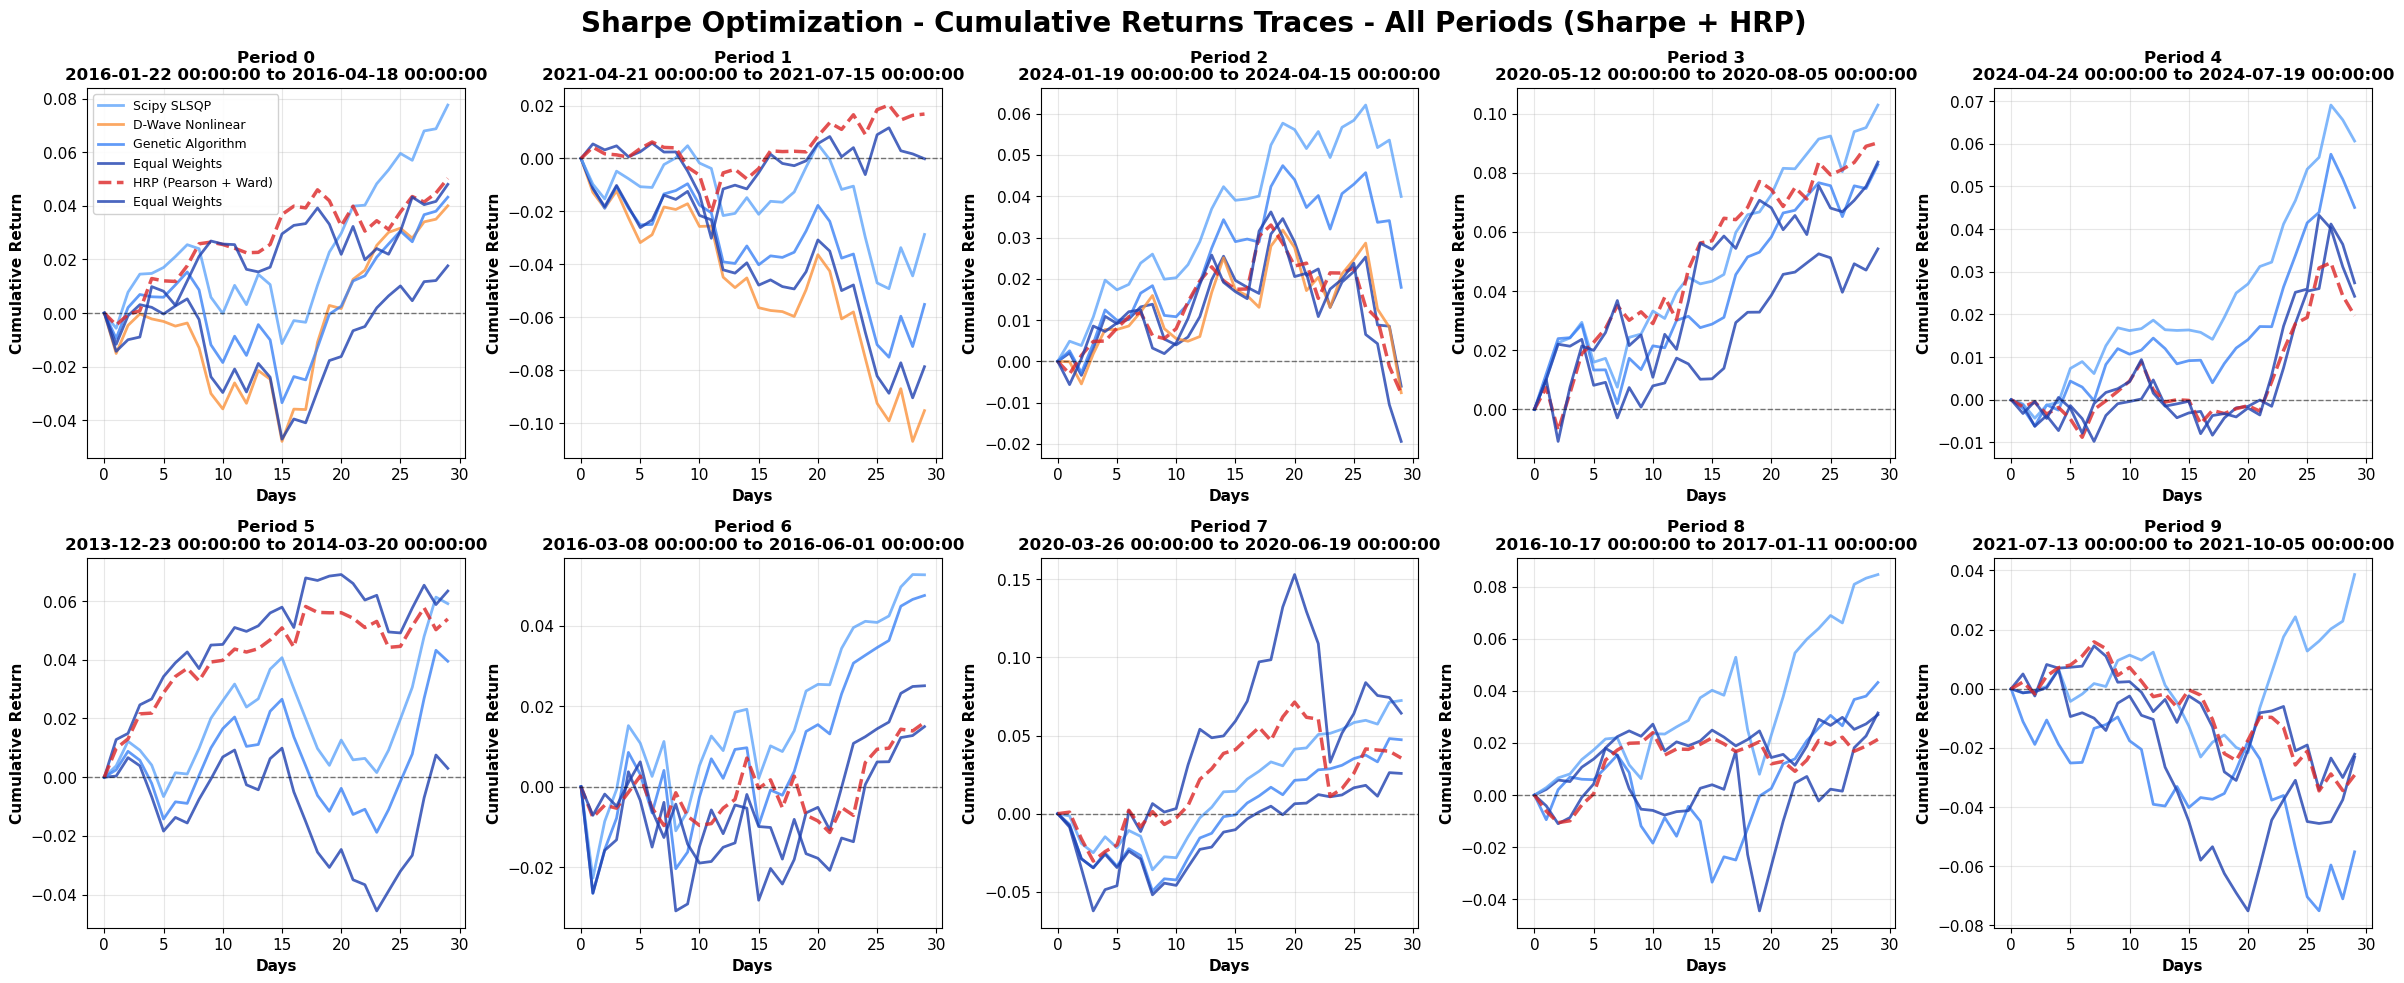


PERIOD-BY-PERIOD SUMMARY

Period 0:
--------------------------------------------------
  Scipy SLSQP              : Return =   0.0776 (  7.76%), Time = 2299.47s
  HRP (Pearson + Ward)     : Return =   0.0502 (  5.02%), Time =   17.63s
  Equal Weights            : Return =   0.0480 (  4.80%), Time =    0.09s
  Genetic Algorithm        : Return =   0.0432 (  4.32%), Time = 4359.36s
  D-Wave Nonlinear         : Return =   0.0400 (  4.00%), Time = 6732.33s
  Equal Weights            : Return =   0.0176 (  1.76%), Time =    0.10s
  ✓ Best: Scipy SLSQP (0.0776)

Period 1:
--------------------------------------------------
  HRP (Pearson + Ward)     : Return =   0.0168 (  1.68%), Time =   18.00s
  Equal Weights            : Return =  -0.0001 ( -0.01%), Time =    0.09s
  Scipy SLSQP              : Return =  -0.0287 ( -2.87%), Time = 2042.80s
  Genetic Algorithm        : Return =  -0.0551 ( -5.51%), Time = 4357.10s
  Equal Weights            : Return =  -0.0786 ( -7.86%), Time =    0.10s
  D-W

In [11]:
# Plot cumulative returns traces for all periods comparing all solvers
print("=" * 100)
print("CUMULATIVE RETURNS TRACES - ALL PERIODS COMPARISON (Sharpe + HRP)")
print("=" * 100)

# Get unique periods and solvers
periods = sorted(df_wide['period'].unique())
solvers = sorted(df_wide['solver_name'].unique())

print(f"\nPlotting {len(periods)} periods with {len(solvers)} solvers")

# Define colors for each solver (consistent across all plots)
solver_colors = {
    'Equal Weights': '#1E40AF',           # Deep blue
    'Genetic Algorithm': '#3B82F6',       # Medium blue
    'Scipy SLSQP': '#60A5FA',             # Light blue
    'HRP (Pearson + Ward)': '#DC2626',    # Red - HRP
    'D-Wave Nonlinear': '#FB923C'         # Orange
}

# Create subplots - 2 rows x 5 columns for 10 periods
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('Sharpe Optimization - Cumulative Returns Traces - All Periods (Sharpe + HRP)', fontsize=20, fontweight='bold')
axes = axes.flatten()

for idx, period in enumerate(periods):
    ax = axes[idx]
    
    # Get data for this period
    period_data = df_wide[df_wide['period'] == period]
    
    # Plot each solver's trace
    for _, row in period_data.iterrows():
        solver_name = row['solver_name']
        portfolio_returns = row['portfolio_returns']
        start_date = row['start_date']
        end_date = row['end_date']
        
        if portfolio_returns is not None and hasattr(portfolio_returns, '__len__'):
            returns_array = np.array(portfolio_returns)
            if len(returns_array) > 0:
                # Create time axis
                time_axis = np.arange(len(returns_array))
                
                # Plot the trace with HRP having a different line style
                color = solver_colors.get(solver_name, '#000000')
                linestyle = '-' if 'HRP' not in solver_name else '--'
                linewidth = 2.5 if 'HRP' in solver_name else 2
                ax.plot(time_axis, returns_array, 
                       label=solver_name, 
                       color=color, 
                       linewidth=linewidth,
                       linestyle=linestyle,
                       alpha=0.8)
    
    # Format the subplot
    ax.set_title(f'Period {period}\n{start_date} to {end_date}', 
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Days', fontweight='bold')
    ax.set_ylabel('Cumulative Return', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sharpe_all_methods_cumulative_returns_all_periods.png'), dpi=300, bbox_inches='tight')
print("Saved: sharpe_all_methods_cumulative_returns_all_periods.png")
plt.show()

# Print summary statistics for each period
print("\n" + "=" * 100)
print("PERIOD-BY-PERIOD SUMMARY")
print("=" * 100)

for period in periods:
    period_data = df_wide[df_wide['period'] == period]
    valid_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 50)
        
        # Sort by final return
        sorted_data = valid_data.sort_values('final_return', ascending=False)
        
        for _, row in sorted_data.iterrows():
            solver_name = row['solver_name']
            final_return = row['final_return']
            exec_time = row['execution_time']
            print(f"  {solver_name:25s}: Return = {final_return:>8.4f} ({final_return*100:>6.2f}%), Time = {exec_time:>7.2f}s")
        
        best = sorted_data.iloc[0]
        print(f"  ✓ Best: {best['solver_name']} ({best['final_return']:.4f})")


AVERAGE PERFORMANCE ACROSS ALL PERIODS (Sharpe + HRP)

Solver Performance Summary:
----------------------------------------------------------------------------------------------------
              Solver  Avg_Return  Std_Return     Avg_Time     Std_Time  N_Periods
    D-Wave Nonlinear   -0.020948    0.068598 31341.851780 47596.141218          3
       Equal Weights    0.018227    0.037337     0.099710     0.016690         20
   Genetic Algorithm    0.025620    0.045338  4358.000953     9.631542         10
HRP (Pearson + Ward)    0.026674    0.033326    17.951024     0.241631         10
         Scipy SLSQP    0.055973    0.035796  2411.137129   481.131511         10
Saved: sharpe_all_methods_average_performance.png


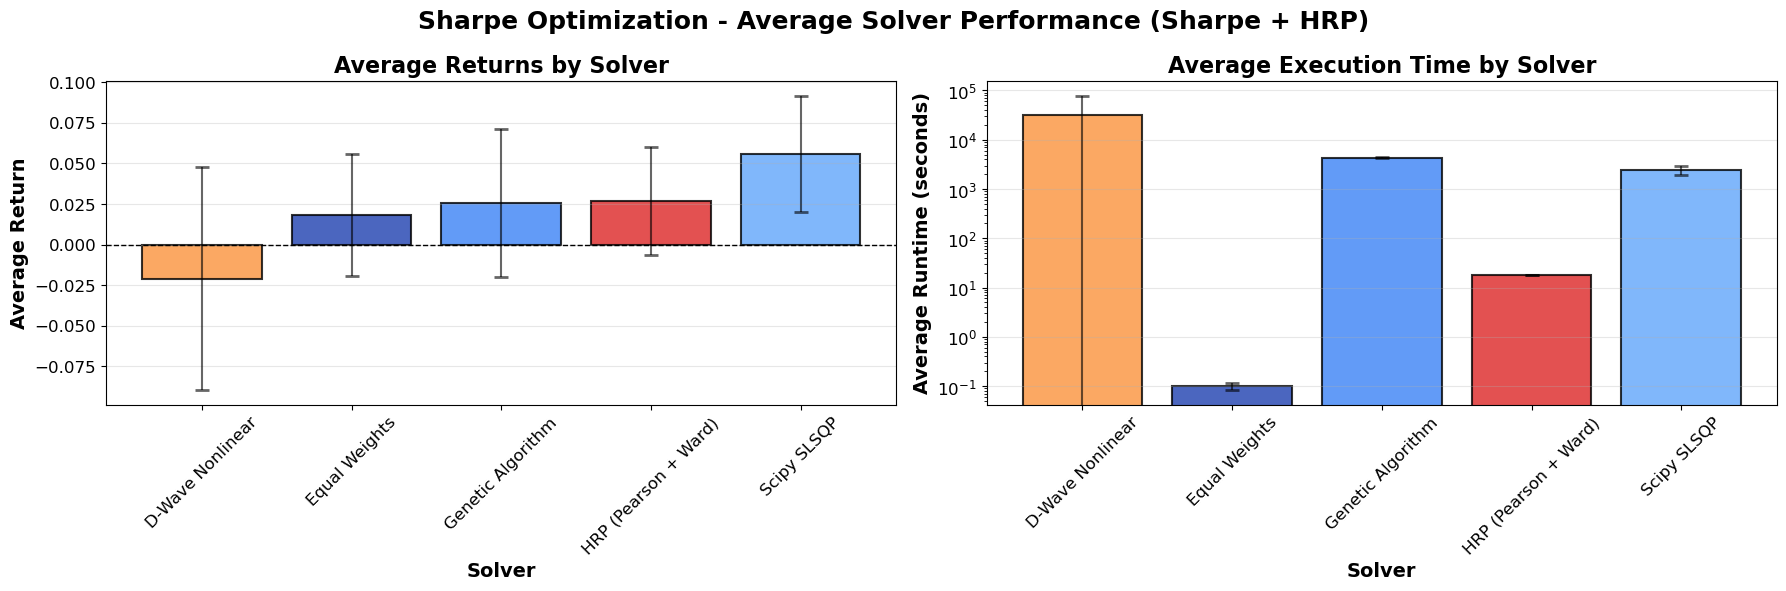


KEY INSIGHTS

Best Average Return: Scipy SLSQP (0.0560 ± 0.0358)
Worst Average Return: D-Wave Nonlinear (-0.0209 ± 0.0686)
Fastest Solver: Equal Weights (0.10s ± 0.02s)
Slowest Solver: D-Wave Nonlinear (31341.85s ± 47596.14s)
Most Consistent: HRP (Pearson + Ward) (Std Dev: 0.0333)

Best Return/Time Efficiency: Equal Weights (0.182799 return/sec)


In [12]:
# Average Performance Analysis - Returns and Runtime
print("\n" + "=" * 100)
print("AVERAGE PERFORMANCE ACROSS ALL PERIODS (Sharpe + HRP)")
print("=" * 100)

# Calculate average statistics per solver
solver_stats = []

for solver_name in sorted(df_wide['solver_name'].unique()):
    solver_data = df_wide[df_wide['solver_name'] == solver_name]
    valid_data = solver_data[solver_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        avg_return = valid_data['final_return'].mean()
        std_return = valid_data['final_return'].std()
        avg_time = valid_data['execution_time'].mean()
        std_time = valid_data['execution_time'].std()
        n_periods = len(valid_data)
        
        solver_stats.append({
            'Solver': solver_name,
            'Avg_Return': avg_return,
            'Std_Return': std_return,
            'Avg_Time': avg_time,
            'Std_Time': std_time,
            'N_Periods': n_periods
        })

df_stats = pd.DataFrame(solver_stats)

# Print summary table
print("\nSolver Performance Summary:")
print("-" * 100)
print(df_stats.to_string(index=False))

# Create barplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Sharpe Optimization - Average Solver Performance (Sharpe + HRP)', fontsize=18, fontweight='bold')

# Define consistent colors
solver_colors = {
    'Equal Weights': '#1E40AF',           # Deep blue
    'Genetic Algorithm': '#3B82F6',       # Medium blue
    'Scipy SLSQP': '#60A5FA',             # Light blue
    'HRP (Pearson + Ward)': '#DC2626',    # Red - HRP
    'D-Wave Nonlinear': '#FB923C'         # Orange
}

# 1. Average Returns Barplot
colors_returns = [solver_colors.get(solver, '#000000') for solver in df_stats['Solver']]
bars1 = ax1.bar(df_stats['Solver'], df_stats['Avg_Return'], 
               color=colors_returns, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add error bars for standard deviation
ax1.errorbar(df_stats['Solver'], df_stats['Avg_Return'], 
            yerr=df_stats['Std_Return'], 
            fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.6)

ax1.set_ylabel('Average Return', fontweight='bold', fontsize=14)
ax1.set_xlabel('Solver', fontweight='bold', fontsize=14)
ax1.set_title('Average Returns by Solver', fontweight='bold', fontsize=16)
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 2. Average Runtime Barplot
colors_time = [solver_colors.get(solver, '#000000') for solver in df_stats['Solver']]
bars2 = ax2.bar(df_stats['Solver'], df_stats['Avg_Time'], 
               color=colors_time, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add error bars for standard deviation
ax2.errorbar(df_stats['Solver'], df_stats['Avg_Time'], 
            yerr=df_stats['Std_Time'], 
            fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.6)

ax2.set_ylabel('Average Runtime (seconds)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Solver', fontweight='bold', fontsize=14)
ax2.set_title('Average Execution Time by Solver', fontweight='bold', fontsize=16)
ax2.tick_params(axis='x', rotation=45, labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_yscale('log')  # Log scale for better visualization if times vary widely

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sharpe_all_methods_average_performance.png'), dpi=300, bbox_inches='tight')
print("Saved: sharpe_all_methods_average_performance.png")
plt.show()

# Print key insights
print("\n" + "=" * 100)
print("KEY INSIGHTS")
print("=" * 100)

best_return = df_stats.loc[df_stats['Avg_Return'].idxmax()]
worst_return = df_stats.loc[df_stats['Avg_Return'].idxmin()]
fastest = df_stats.loc[df_stats['Avg_Time'].idxmin()]
slowest = df_stats.loc[df_stats['Avg_Time'].idxmax()]
most_consistent = df_stats.loc[df_stats['Std_Return'].idxmin()]

print(f"\nBest Average Return: {best_return['Solver']} ({best_return['Avg_Return']:.4f} ± {best_return['Std_Return']:.4f})")
print(f"Worst Average Return: {worst_return['Solver']} ({worst_return['Avg_Return']:.4f} ± {worst_return['Std_Return']:.4f})")
print(f"Fastest Solver: {fastest['Solver']} ({fastest['Avg_Time']:.2f}s ± {fastest['Std_Time']:.2f}s)")
print(f"Slowest Solver: {slowest['Solver']} ({slowest['Avg_Time']:.2f}s ± {slowest['Std_Time']:.2f}s)")
print(f"Most Consistent: {most_consistent['Solver']} (Std Dev: {most_consistent['Std_Return']:.4f})")

# Calculate performance-to-time ratio (return per second)
df_stats['Return_Per_Second'] = df_stats['Avg_Return'] / df_stats['Avg_Time']
best_efficiency = df_stats.loc[df_stats['Return_Per_Second'].idxmax()]
print(f"\nBest Return/Time Efficiency: {best_efficiency['Solver']} ({best_efficiency['Return_Per_Second']:.6f} return/sec)")

In [13]:
def extract_weights_from_results(df_subset):
    """Extract portfolio weights from all results in a dataset subset."""
    weights_by_solver = {}
    
    for _, result in df_subset.iterrows():
        solver_name = result['solver_name']
        data = result['data']
        
        if data is not None:
            # Try different possible keys for weights
            weights = None
            
            # Check for weights_history first (most likely location)
            if 'weights_history' in data and data['weights_history'] is not None:
                weights_hist = data['weights_history']
                
                # weights_history might be a list of weight arrays or a single array
                if isinstance(weights_hist, (list, tuple)) and len(weights_hist) > 0:
                    # Take the final weights (last entry)
                    weights = np.array(weights_hist[-1])
                elif hasattr(weights_hist, 'shape') or hasattr(weights_hist, '__len__'):
                    # It's already a weights array
                    weights = np.array(weights_hist)
            
            # Fallback to other possible keys
            if weights is None:
                possible_weight_keys = [
                    'portfolio_weights',
                    'weights', 
                    'optimal_weights',
                    'final_weights',
                    'solution_weights'
                ]
                
                for key in possible_weight_keys:
                    if key in data and data[key] is not None:
                        weights = np.array(data[key])
                        break
            
            if weights is not None:
                # Ensure weights is 1D
                if weights.ndim > 1:
                    weights = weights.flatten()
                
                # Filter out zero or very small weights
                non_zero_weights = weights[weights > 1e-6]
                
                if len(non_zero_weights) > 0:
                    if solver_name not in weights_by_solver:
                        weights_by_solver[solver_name] = []
                    weights_by_solver[solver_name].extend(non_zero_weights.tolist())
                    
                    # Debug: print info for first result per solver
                    if len(weights_by_solver[solver_name]) == len(non_zero_weights):
                        print(f"Found weights for {solver_name}: {len(non_zero_weights)} positions, sum={np.sum(non_zero_weights):.6f}")
    
    return weights_by_solver

def plot_weight_distribution_histograms(df_subset, dataset_name, bins=None):
    """Plot weight distribution histograms for all solvers in a dataset."""
    
    weights_by_solver = extract_weights_from_results(df_subset)
    
    if not weights_by_solver:
        print(f"No weight data found for {dataset_name}")
        return
    
    print(f"\n{dataset_name} - Weight Distribution Analysis:")
    print("=" * 60)
    
    n_solvers = len(weights_by_solver)
    if n_solvers == 0:
        return
    
    # Determine grid size and bins
    if n_solvers <= 4:
        rows, cols = 2, 2
        default_bins = 20
    elif n_solvers <= 6:
        rows, cols = 2, 3
        default_bins = 25
    else:
        rows, cols = 3, 3
        default_bins = 30
    
    if bins is None:
        bins = default_bins
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    fig.suptitle(f'{dataset_name} - Portfolio Weight Distributions by Solver', 
                 fontsize=18, fontweight='bold')
    
    # Flatten axes array for easy indexing
    if n_solvers == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    colors = ['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC', '#FF6347', '#8A2BE2', '#00CED1', '#FF1493']
    
    for idx, (solver_name, weights) in enumerate(weights_by_solver.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        weights_array = np.array(weights)
        
        # Plot histogram
        ax.hist(weights_array, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                edgecolor='black', density=True)
        
        # Calculate statistics
        mean_weight = np.mean(weights_array)
        std_weight = np.std(weights_array)
        max_weight = np.max(weights_array)
        min_weight = np.min(weights_array)
        median_weight = np.median(weights_array)
        n_positions = len(weights_array)
        
        ax.set_xlabel('Weight', fontweight='bold')
        ax.set_ylabel('Density', fontweight='bold')
        ax.set_title(f'{solver_name}\n({n_positions} positions)', fontweight='bold')
        ax.set_yscale('log')  # Set y-axis to log scale
        ax.grid(True, alpha=0.3)
        
        # Add statistics text box
        stats_text = f'Mean: {mean_weight:.4f}\nStd: {std_weight:.4f}\nMax: {max_weight:.4f}'
        ax.text(0.65, 0.85, stats_text, transform=ax.transAxes, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
                fontsize=11, verticalalignment='top')
        
        # Print detailed statistics
        print(f"\n{solver_name}:")
        print(f"  Total positions: {n_positions}")
        print(f"  Mean weight: {mean_weight:.6f} ({mean_weight*100:.4f}%)")
        print(f"  Std weight: {std_weight:.6f}")
        print(f"  Min weight: {min_weight:.6f}")
        print(f"  Max weight: {max_weight:.6f} ({max_weight*100:.4f}%)")
        print(f"  Median weight: {median_weight:.6f}")
        
        # Concentration metrics
        sorted_weights = np.sort(weights_array)[::-1]
        if len(sorted_weights) >= 5:
            top5_sum = np.sum(sorted_weights[:5])
            print(f"  Top 5 positions: {top5_sum:.4f} ({top5_sum*100:.2f}%)")
        if len(sorted_weights) >= 10:
            top10_sum = np.sum(sorted_weights[:10])
            print(f"  Top 10 positions: {top10_sum:.4f} ({top10_sum*100:.2f}%)")
        if len(sorted_weights) >= 20:
            top20_sum = np.sum(sorted_weights[:20])
            print(f"  Top 20 positions: {top20_sum:.4f} ({top20_sum*100:.2f}%)")
    
    # Hide unused subplots
    for idx in range(len(weights_by_solver), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    # Save the figure
    artifacts_dir = '../../artifacts'
    filename = f"{dataset_name.lower().replace(' ', '_').replace('-', '_')}_weight_distributions.png"
    plt.savefig(os.path.join(artifacts_dir, filename), dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    plt.show()
    
    return weights_by_solver

## Wide Dataset - Comprehensive Weight Distribution Analysis

This section provides detailed weight distribution analysis for the wide dataset, examining how different solvers allocate weights across the available assets.


WEIGHT DISTRIBUTION ANALYSIS - WIDE DATASET (Sharpe + HRP)

Analyzing how different solvers allocate weights across the 680 available assets...
Found weights for Scipy SLSQP: 20400 positions, sum=30.000000
Found weights for Equal Weights: 20400 positions, sum=30.000000
Found weights for Genetic Algorithm: 20400 positions, sum=30.000000
Found weights for D-Wave Nonlinear: 20400 positions, sum=30.000000
Found weights for HRP (Pearson + Ward): 13170 positions, sum=30.000000

Wide Dataset - Sharpe Optimization (Sharpe + HRP) - Weight Distribution Analysis:

Scipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.002463
  Min weight: 0.001000
  Max weight: 0.014706 (1.4706%)
  Median weight: 0.001000
  Top 5 positions: 0.0735 (7.35%)
  Top 10 positions: 0.1471 (14.71%)
  Top 20 positions: 0.2941 (29.41%)



Equal Weights:
  Total positions: 335700
  Mean weight: 0.001787 (0.1787%)
  Std weight: 0.000394
  Min weight: 0.001471
  Max weight: 0.002278 (0.2278%)
  Median weight: 0.001471
  Top 5 positions: 0.0114 (1.14%)
  Top 10 positions: 0.0228 (2.28%)
  Top 20 positions: 0.0456 (4.56%)

Genetic Algorithm:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.001824
  Min weight: 0.000994
  Max weight: 0.014766 (1.4766%)
  Median weight: 0.000999
  Top 5 positions: 0.0737 (7.37%)
  Top 10 positions: 0.1473 (14.73%)
  Top 20 positions: 0.2940 (29.40%)

D-Wave Nonlinear:
  Total positions: 61200
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.008978
  Min weight: 0.000100
  Max weight: 0.415508 (41.5508%)
  Median weight: 0.000105
  Top 5 positions: 1.7076 (170.76%)
  Top 10 positions: 2.9344 (293.44%)
  Top 20 positions: 5.1288 (512.88%)

HRP (Pearson + Ward):
  Total positions: 131700
  Mean weight: 0.002278 (0.2278%)
  Std weight: 0.002380
  Min weight: 0.000020
 

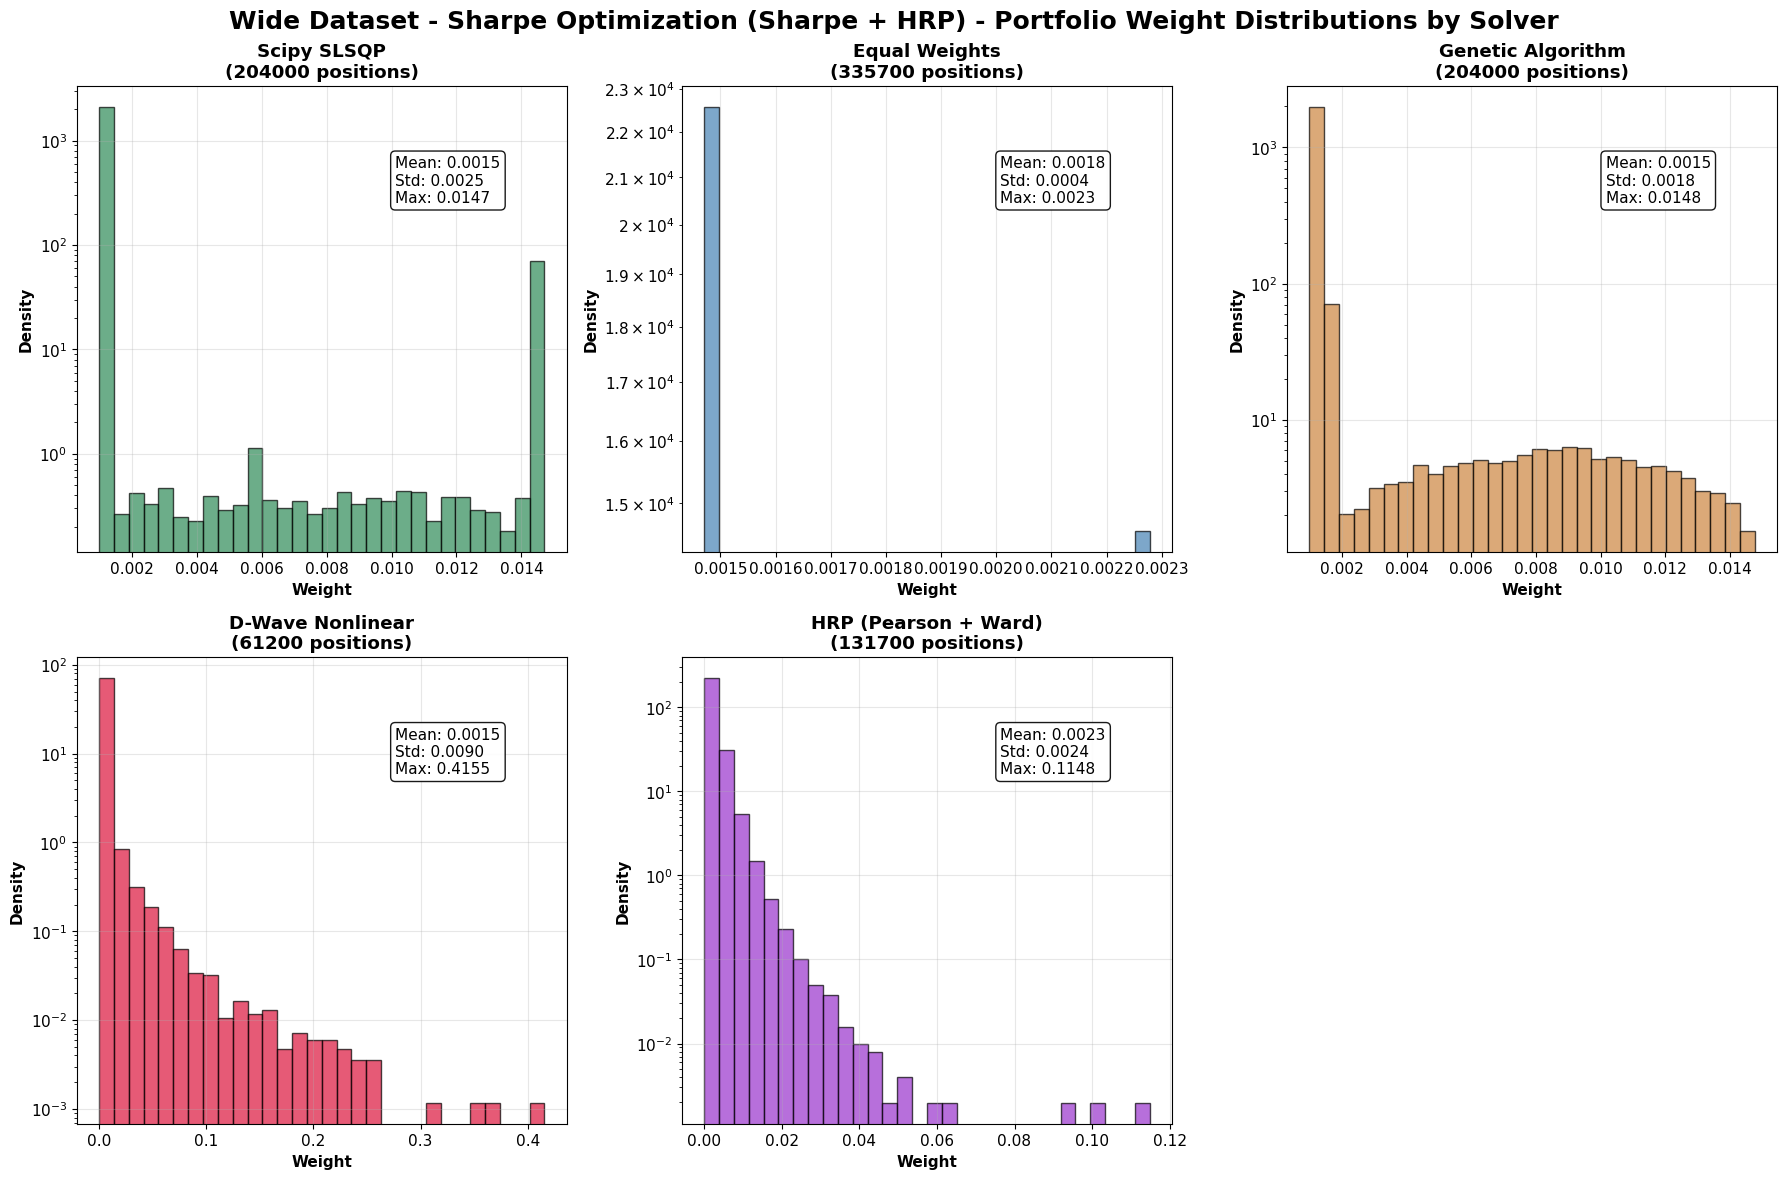


WEIGHT CONCENTRATION ANALYSIS

D-Wave Nonlinear:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 5.065125
  Effective number of positions: 0.20
  Total positions: 61200
  Concentration ratio: 309985.6517
  Gini coefficient: 0.8969 (0=perfect equality, 1=perfect inequality)

Equal Weights:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 1.124548
  Effective number of positions: 0.89
  Total positions: 335700
  Concentration ratio: 377510.6861
  Gini coefficient: 0.1077 (0=perfect equality, 1=perfect inequality)

Genetic Algorithm:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 1.119526
  Effective number of positions: 0.89
  Total positions: 204000
  Concentration ratio: 228383.3816
  Gini coefficient: 0.2968 (0=perfect equality, 1=perfect inequality)

HRP (Pearson + Ward):
------------------------------------------------------------
  Herf

In [14]:
# Comprehensive Weight Distribution Analysis for Wide Dataset
print("\n" + "=" * 100)
print("WEIGHT DISTRIBUTION ANALYSIS - WIDE DATASET (Sharpe + HRP)")
print("=" * 100)
print("\nAnalyzing how different solvers allocate weights across the 680 available assets...")

# Run weight distribution analysis
weights_by_solver = plot_weight_distribution_histograms(
    df_wide, 
    'Wide Dataset - Sharpe Optimization (Sharpe + HRP)',
    bins=30
)

# Additional analysis: Weight concentration
print("\n" + "=" * 100)
print("WEIGHT CONCENTRATION ANALYSIS")
print("=" * 100)

for solver_name in sorted(weights_by_solver.keys()):
    weights = np.array(weights_by_solver[solver_name])
    
    print(f"\n{solver_name}:")
    print("-" * 60)
    
    # Calculate Herfindahl-Hirschman Index (HHI) - measure of concentration
    # HHI ranges from 1/n (perfectly diversified) to 1 (fully concentrated)
    hhi = np.sum(weights ** 2)
    
    # Effective number of positions
    effective_n = 1 / hhi if hhi > 0 else 0
    
    print(f"  Herfindahl-Hirschman Index (HHI): {hhi:.6f}")
    print(f"  Effective number of positions: {effective_n:.2f}")
    print(f"  Total positions: {len(weights)}")
    print(f"  Concentration ratio: {hhi * len(weights):.4f}")
    
    # Gini coefficient - measure of inequality
    sorted_weights = np.sort(weights)
    n = len(sorted_weights)
    cumsum = np.cumsum(sorted_weights)
    gini = (2 * np.sum((np.arange(1, n+1)) * sorted_weights)) / (n * np.sum(sorted_weights)) - (n + 1) / n
    print(f"  Gini coefficient: {gini:.4f} (0=perfect equality, 1=perfect inequality)")

COMPREHENSIVE COMPARISON: SHARPE vs QUBO vs HRP

Found 58 QUBO result files
Loaded 38 QUBO results
QUBO Solvers: ['bf', 'dwave-cqm', 'ew', 'ga']

Total methods in comparison: 6
Methods: ['HRP (Pearson + Ward)', 'QUBO - Genetic Algorithm', 'QUBO - Scipy SLSQP', 'Sharpe - D-Wave Nonlinear', 'Sharpe - Genetic Algorithm', 'Sharpe - Scipy SLSQP']

PLOTTING COMPREHENSIVE COMPARISON - ALL 10 PERIODS

Saved: comprehensive_comparison_all_methods_all_periods.png


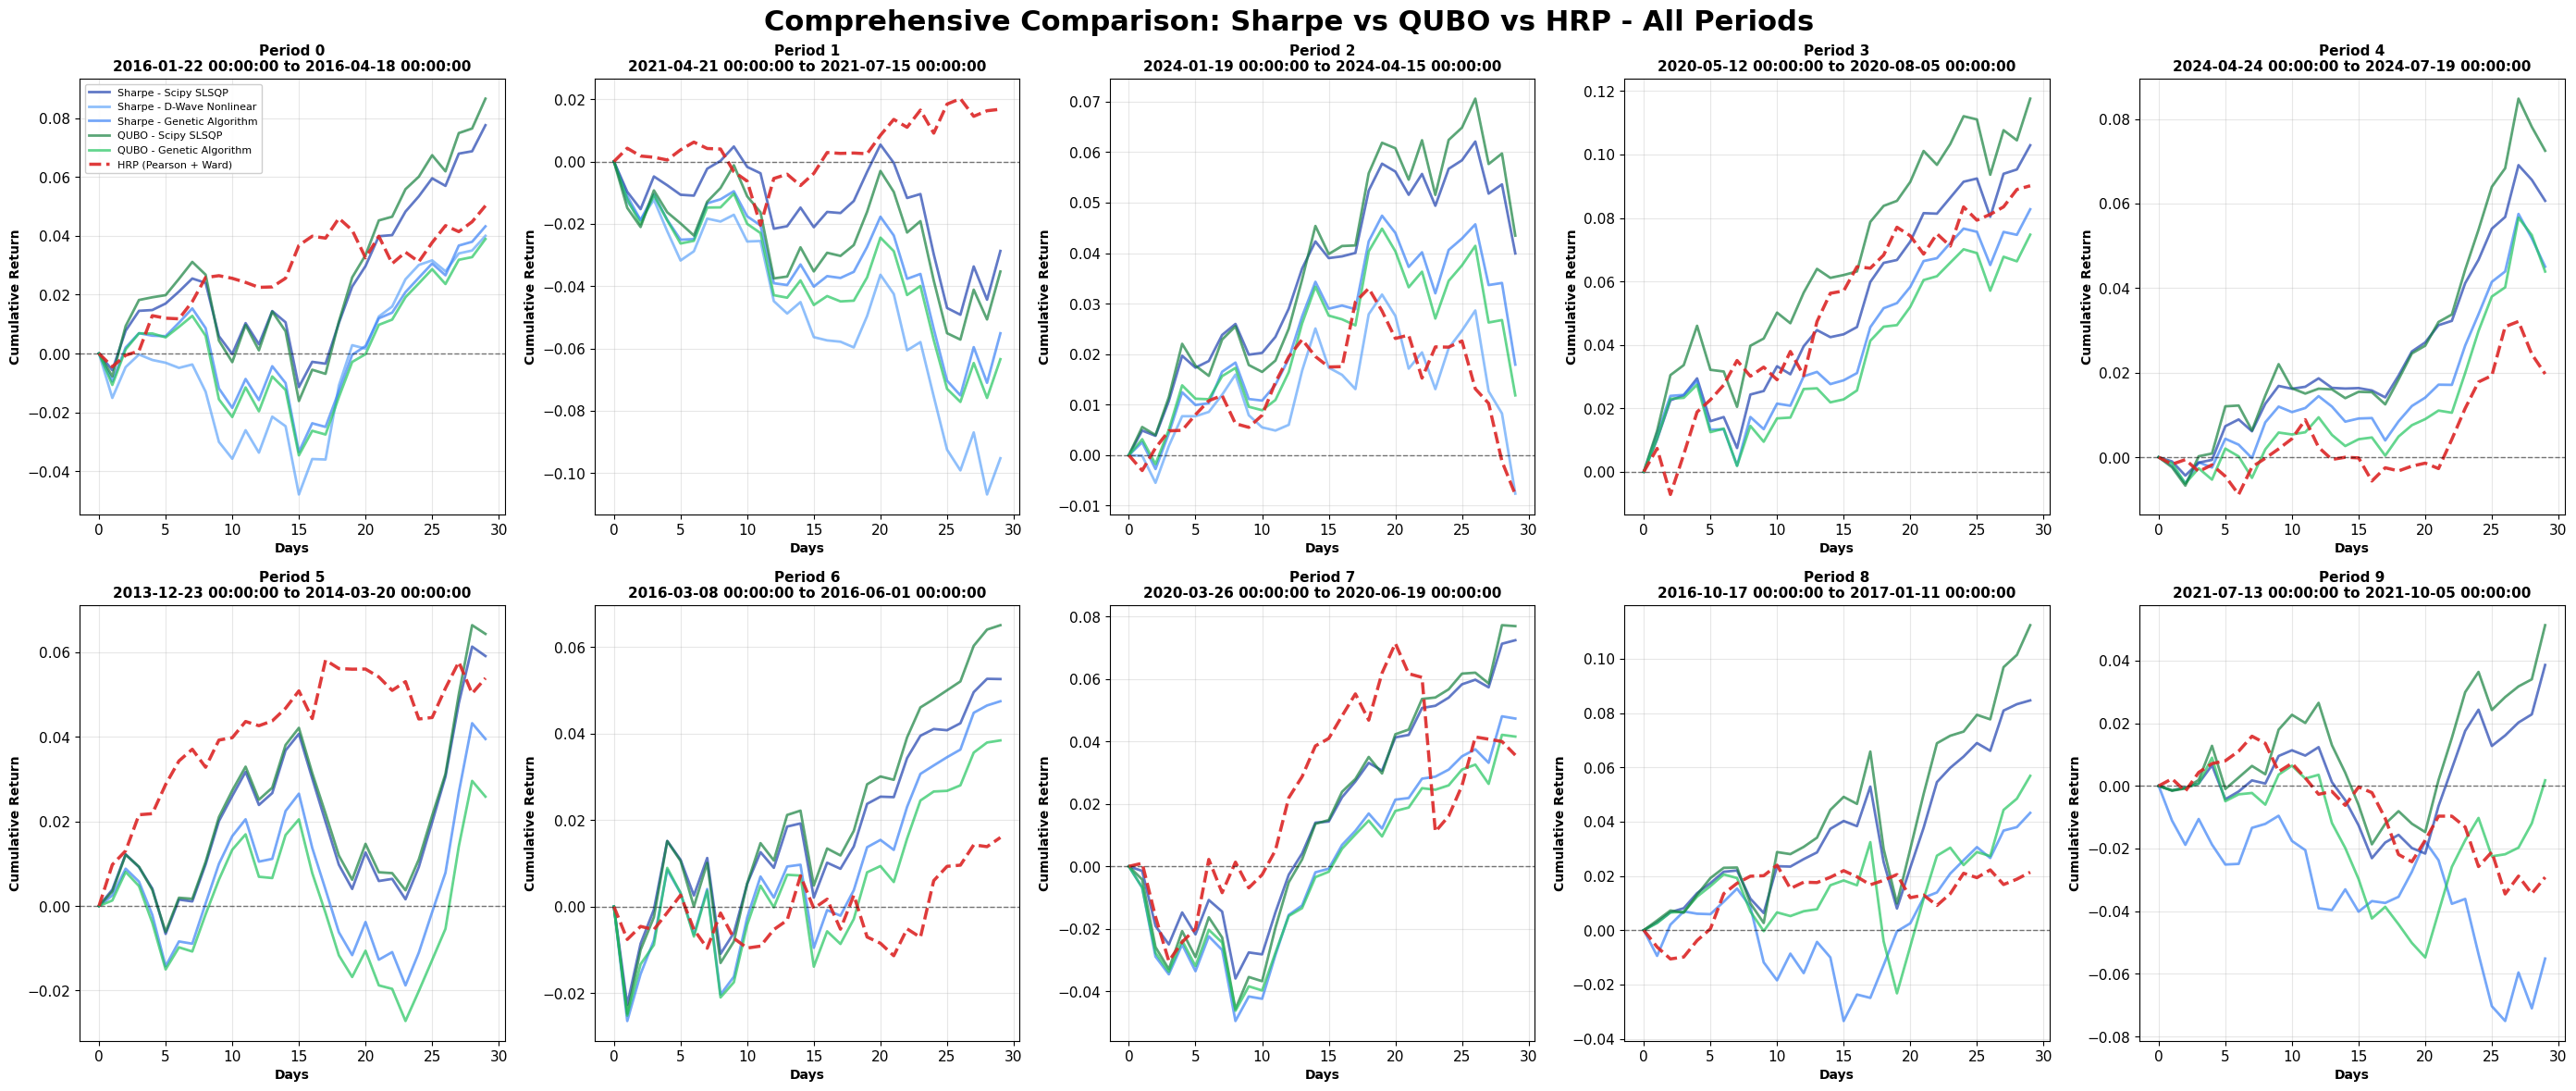


COMPREHENSIVE PERIOD-BY-PERIOD SUMMARY

Period 0:
----------------------------------------------------------------------
  QUBO - Scipy SLSQP            : Return =   0.0866 (  8.66%), Time = 3343.62s
  Sharpe - Scipy SLSQP          : Return =   0.0776 (  7.76%), Time = 2299.47s
  HRP (Pearson + Ward)          : Return =   0.0502 (  5.02%), Time =   17.63s
  Sharpe - Genetic Algorithm    : Return =   0.0432 (  4.32%), Time = 4359.36s
  Sharpe - D-Wave Nonlinear     : Return =   0.0400 (  4.00%), Time = 6732.33s
  QUBO - Genetic Algorithm      : Return =   0.0389 (  3.89%), Time = 4346.44s

  ✓ Best: QUBO - Scipy SLSQP (0.0866)

Period 1:
----------------------------------------------------------------------
  HRP (Pearson + Ward)          : Return =   0.0168 (  1.68%), Time =   18.00s
  Sharpe - Scipy SLSQP          : Return =  -0.0287 ( -2.87%), Time = 2042.80s
  QUBO - Scipy SLSQP            : Return =  -0.0353 ( -3.53%), Time = 3264.43s
  Sharpe - Genetic Algorithm    : Return =  -0

In [15]:
# Load QUBO results for comprehensive comparison
print("=" * 100)
print("COMPREHENSIVE COMPARISON: SHARPE vs QUBO vs HRP")
print("=" * 100)

def load_qubo_results(qubo_dir='../../results/qubo'):
    """Load QUBO optimization results."""
    results = []
    
    qubo_files = glob.glob(os.path.join(qubo_dir, '*.pkl'))
    print(f"\nFound {len(qubo_files)} QUBO result files")
    
    for file_path in qubo_files:
        # Parse filename
        dataset, period, solver = parse_filename(file_path)
        
        if dataset is not None and dataset == 'wide':
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Extract key metrics
                portfolio_returns = data.get('portfolio_cumulative_returns', [])
                execution_time = data.get('total_run_time', 0)
                start_date = data.get('start_date')
                end_date = data.get('end_date')
                
                # Calculate final return
                final_return = None
                if portfolio_returns is not None:
                    try:
                        if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                    except:
                        pass
                
                results.append({
                    'filename': os.path.basename(file_path),
                    'method': 'QUBO',
                    'period': period,
                    'solver': solver,
                    'portfolio_returns': portfolio_returns,
                    'final_return': final_return,
                    'execution_time': execution_time,
                    'start_date': start_date,
                    'end_date': end_date
                })
    
    return results

# Load QUBO results
qubo_results = load_qubo_results()
df_qubo = pd.DataFrame(qubo_results)

print(f"Loaded {len(df_qubo)} QUBO results")
print(f"QUBO Solvers: {sorted(df_qubo['solver'].unique())}")

# Prepare Sharpe results for comparison
df_sharpe_comparison = df_wide.copy()
df_sharpe_comparison['method'] = 'Sharpe'

# Create combined dataset for comparison
# Map solver names for the comparison
comparison_data = []

# Add Sharpe results (scipy, dwave-nl, ga)
for _, row in df_sharpe_comparison.iterrows():
    solver = row['solver']
    if solver in ['bf', 'dwave-nl', 'ga']:
        comparison_data.append({
            'method_solver': f"Sharpe - {row['solver_name']}",
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date'],
            'method': 'Sharpe',
            'solver': solver
        })

# Add QUBO results (bf, dwave_cqm, ga)
qubo_solver_names = {
    'bf': 'Scipy SLSQP',
    'dwave_cqm': 'D-Wave CQM',
    'ga': 'Genetic Algorithm'
}

for _, row in df_qubo.iterrows():
    solver = row['solver']
    if solver in ['bf', 'dwave_cqm', 'ga']:
        solver_name = qubo_solver_names.get(solver, solver)
        comparison_data.append({
            'method_solver': f"QUBO - {solver_name}",
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date'],
            'method': 'QUBO',
            'solver': solver
        })

# Add HRP results
for _, row in df_sharpe_comparison.iterrows():
    if row['solver'] == 'hrp_pearson_ward':
        comparison_data.append({
            'method_solver': 'HRP (Pearson + Ward)',
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date'],
            'method': 'HRP',
            'solver': 'hrp_pearson_ward'
        })

df_comparison = pd.DataFrame(comparison_data)

print(f"\nTotal methods in comparison: {len(df_comparison['method_solver'].unique())}")
print(f"Methods: {sorted(df_comparison['method_solver'].unique())}")

# Create comprehensive comparison plot
print("\n" + "=" * 100)
print("PLOTTING COMPREHENSIVE COMPARISON - ALL 10 PERIODS")
print("=" * 100)

# Define colors for each method
method_colors = {
    'Sharpe - Scipy SLSQP': '#1E40AF',        # Deep blue
    'Sharpe - Genetic Algorithm': '#3B82F6',  # Medium blue  
    'Sharpe - D-Wave Nonlinear': '#60A5FA',   # Light blue
    'QUBO - Scipy SLSQP': '#15803D',          # Deep green
    'QUBO - Genetic Algorithm': '#22C55E',    # Medium green
    'QUBO - D-Wave CQM': '#86EFAC',           # Light green
    'HRP (Pearson + Ward)': '#DC2626'         # Red
}

# Create subplots - 2 rows x 5 columns for 10 periods
fig, axes = plt.subplots(2, 5, figsize=(28, 12))
fig.suptitle('Comprehensive Comparison: Sharpe vs QUBO vs HRP - All Periods', fontsize=22, fontweight='bold')
axes = axes.flatten()

periods = sorted(df_comparison['period'].unique())

for idx, period in enumerate(periods):
    ax = axes[idx]
    
    # Get data for this period
    period_data = df_comparison[df_comparison['period'] == period]
    
    # Plot each method's trace
    for _, row in period_data.iterrows():
        method_solver = row['method_solver']
        portfolio_returns = row['portfolio_returns']
        start_date = row['start_date']
        end_date = row['end_date']
        
        if portfolio_returns is not None and hasattr(portfolio_returns, '__len__'):
            returns_array = np.array(portfolio_returns)
            if len(returns_array) > 0:
                # Create time axis
                time_axis = np.arange(len(returns_array))
                
                # Plot styling
                color = method_colors.get(method_solver, '#000000')
                linestyle = '--' if 'HRP' in method_solver else '-'
                linewidth = 2.5 if 'HRP' in method_solver else 2
                alpha = 0.9 if 'HRP' in method_solver else 0.7
                
                ax.plot(time_axis, returns_array, 
                       label=method_solver, 
                       color=color, 
                       linewidth=linewidth,
                       linestyle=linestyle,
                       alpha=alpha)
    
    # Format the subplot
    ax.set_title(f'Period {period}\n{start_date} to {end_date}', 
                fontweight='bold', fontsize=11)
    ax.set_xlabel('Days', fontweight='bold', fontsize=10)
    ax.set_ylabel('Cumulative Return', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.95, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'comprehensive_comparison_all_methods_all_periods.png'), dpi=300, bbox_inches='tight')
print("\nSaved: comprehensive_comparison_all_methods_all_periods.png")
plt.show()

# Print summary statistics for each period
print("\n" + "=" * 100)
print("COMPREHENSIVE PERIOD-BY-PERIOD SUMMARY")
print("=" * 100)

for period in periods:
    period_data = df_comparison[df_comparison['period'] == period]
    valid_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 70)
        
        # Sort by final return
        sorted_data = valid_data.sort_values('final_return', ascending=False)
        
        for _, row in sorted_data.iterrows():
            method_solver = row['method_solver']
            final_return = row['final_return']
            exec_time = row['execution_time']
            print(f"  {method_solver:30s}: Return = {final_return:>8.4f} ({final_return*100:>6.2f}%), Time = {exec_time:>7.2f}s")
        
        best = sorted_data.iloc[0]
        print(f"\n  ✓ Best: {best['method_solver']} ({best['final_return']:.4f})")

# Overall comparison statistics
print("\n" + "=" * 100)
print("OVERALL AVERAGE PERFORMANCE COMPARISON")
print("=" * 100)

comparison_stats = []
for method_solver in sorted(df_comparison['method_solver'].unique()):
    method_data = df_comparison[df_comparison['method_solver'] == method_solver]
    valid_data = method_data[method_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        avg_return = valid_data['final_return'].mean()
        std_return = valid_data['final_return'].std()
        avg_time = valid_data['execution_time'].mean()
        n_periods = len(valid_data)
        
        comparison_stats.append({
            'Method': method_solver,
            'Avg_Return': avg_return,
            'Std_Return': std_return,
            'Avg_Time': avg_time,
            'N_Periods': n_periods
        })

df_comparison_stats = pd.DataFrame(comparison_stats)
df_comparison_stats = df_comparison_stats.sort_values('Avg_Return', ascending=False)

print("\nComprehensive Performance Summary (sorted by average return):")
print("-" * 100)
print(df_comparison_stats.to_string(index=False))

# Highlight best performers
print("\n" + "=" * 100)
print("KEY FINDINGS")
print("=" * 100)

best_return = df_comparison_stats.iloc[0]
print(f"\n✓ Best Average Return: {best_return['Method']}")
print(f"  Return: {best_return['Avg_Return']:.4f} ± {best_return['Std_Return']:.4f}")
print(f"  Avg Time: {best_return['Avg_Time']:.2f}s")

fastest = df_comparison_stats.loc[df_comparison_stats['Avg_Time'].idxmin()]
print(f"\n✓ Fastest: {fastest['Method']}")
print(f"  Avg Time: {fastest['Avg_Time']:.2f}s")
print(f"  Return: {fastest['Avg_Return']:.4f} ± {fastest['Std_Return']:.4f}")

# Compare by method category
print("\n" + "=" * 100)
print("COMPARISON BY METHOD CATEGORY")
print("=" * 100)

for method in ['Sharpe', 'QUBO', 'HRP']:
    method_subset = df_comparison_stats[df_comparison_stats['Method'].str.contains(method)]
    if len(method_subset) > 0:
        print(f"\n{method}:")
        print("-" * 50)
        for _, row in method_subset.iterrows():
            print(f"  {row['Method']:30s}: {row['Avg_Return']:.4f} ± {row['Std_Return']:.4f}")
        
        best_in_category = method_subset.iloc[0]
        print(f"  → Best {method}: {best_in_category['Method']}")